In [2]:
#Packages to Import

#Numerical Elements
from numpy.linalg import norm
import numpy as np
from numpy import dot, array, transpose, diag

#Fun Progress Bar
from tqdm.notebook import tqdm

#Misc System (plotting etc)
import sys
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

import pickle
import warnings
warnings.filterwarnings('ignore')


#MCMC Sampliers and Related Utilities
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
%run ../MCMC_Sampliers.ipynb



#Plotting Libraries
import matplotlib.pyplot as plt
from numpy.linalg import norm



plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})


#Some Code to Compute measures of mixing

import numpy as np
from numpy.fft import rfft, irfft

def ess_OLDE(series: np.ndarray) -> float:
    """
    Effective Sample Size of a 1‑D NumPy array using the
    initial‑positive‑sequence rule (Geyer, 1992).

    Parameters
    ----------
    series : array_like, shape (N,)
        Time‑series values f(X₁),…,f(X_N).

    Returns
    -------
    ess : float
        Estimated effective sample size.
    """
    x = np.asarray(series, dtype=float)
    n = x.size
    x -= x.mean()

    # Autocovariances via FFT: O(N log N)
    fft = rfft(x, n=2*n)
    acov = irfft(fft * np.conjugate(fft))[:n] / n
    rho = acov / acov[0]           # normalised autocorrelation

    # Initial‑positive‑sequence truncation
    pos = np.where(rho[1:] > 0)[0]
    k = pos[-1] + 1 if pos.size else 0   # K = last positive lag

    ess = n / (1 + 2 * rho[1:k+1].sum())
    return ess


import numpy as np

def autocorr_func_1d(x):
    """Compute full autocorrelation function for 1D array x."""
    x = np.asarray(x)
    n = len(x)
    x -= x.mean()
    # unbiased variance
    c0 = np.dot(x, x) / n
    # full autocovariance
    acov = np.correlate(x, x, mode="full")[n-1:] / np.arange(n, 0, -1)
    return acov / c0

def ess(x, max_lag=None):
    """
    Effective Sample Size via initial positive sequence:
      ESS = N / [1 + 2 * sum_{k=1}^K rho_k]
    where K is the last lag before rho_k+rho_{k+1} < 0.
    """
    acf = autocorr_func_1d(x)
    N = len(x)
    # choose max_lag if not set
    if max_lag is None:
        max_lag = N//2
    rho = acf[1:max_lag]
    # find where successive pairs go negative
    K = max_lag
    for k in range(0, len(rho)-1, 2):
        if rho[k] + rho[k+1] < 0:
            K = k+1
            break
    tau = 1 + 2 * np.sum(rho[:K])
    return N / tau


def msjd(samples: np.ndarray) -> float:
    """
    Mean‑Squared Jumping Distance.

    Parameters
    ----------
    samples : array_like, shape (N, d)
        Markov‑chain states X₁,…,X_N.

    Returns
    -------
    msjd : float
        Average squared Euclidean distance between successive states.
    """
    diffs = np.diff(samples, axis=0)      # shape (N-1, d)
    return np.mean(np.sum(diffs**2, axis=1))


In [60]:
#Example 1: Perturbed Gaussian Target

#Model Dimension and Parameter Size

NmParaEx1 = 5 #Dimension of the Gaussian Target

cov0 = 5
gam = 1.5
CovEx1 = np.diag([cov0* (j**(-gam)) for j in list(range(1,NmParaEx1+1))])

k0 = 7
k0inv = k0**(-1)
c0inv = Cov[0,0]**(-1)
m = -1

PotEx1 = lambda X : .5*X[0]*(k0inv - c0inv)*X[0] - k0inv*m*X[0]




In [80]:
#Optimal tuning of rho for Example 1

pI = 1
pStep = 5
pF = 101


delRho = .01
burnIn = 1000
NumSamps = 5000

pLstEx1 = []
ESSrhoBestLstEx1 = []
ESSBestLstEx1 = []
MSJDrhoBestLstEx1 = []
MSJDBestLstEx1 = []

q0Ex1 = np.zeros(NmParaEx1)
for p in tqdm(range(pI,pF,pStep)):
    rho = 0
    rhoBestESS = 0
    rhoBestMSJD = 0
    ESSBest = 0
    MSJDBest = 0
    while(rho < 1):
        curSamp = MpCN(q0Ex1,NmParaEx1,CovEx1,rho,PotEx1,p,NumSamps)
        ESSCur = ess(curSamp[burnIn:,0])
        MSJDCur = msjd(curSamp[burnIn:])
        if ESSCur > ESSBest:
            ESSBest = ESSCur
            rhoBestESS = rho
        if MSJDCur > MSJDBest:
            MSJDBest = MSJDCur
            rhoBestMSJD = rho
        rho = rho + delRho
    pLstEx1.append(p)
    ESSBestLstEx1.append(ESSBest)
    ESSrhoBestLstEx1.append(rhoBestESS)
    MSJDBestLstEx1.append(MSJDBest)
    MSJDrhoBestLstEx1.append(rhoBestMSJD)

  
    



  0%|          | 0/20 [00:00<?, ?it/s]

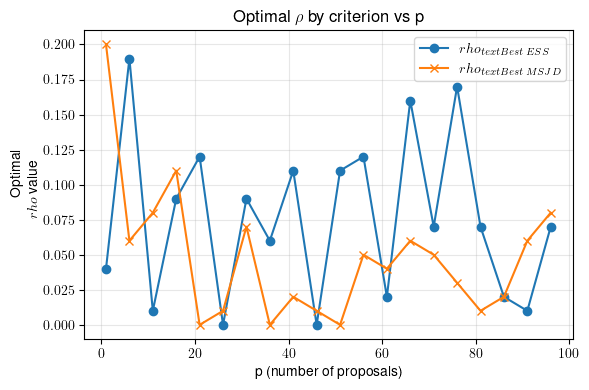

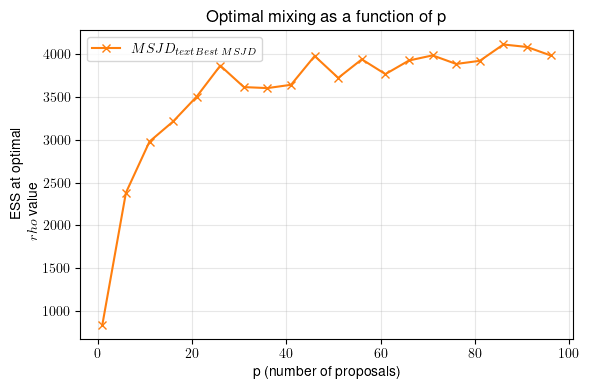

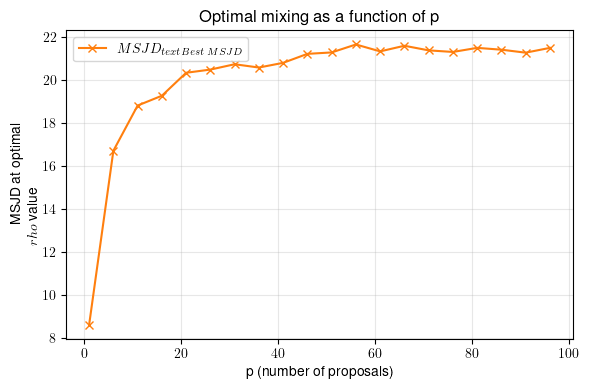

In [81]:
#Saving Experiment

FileNmBase= "Data/Gaussian/"
ExpDes = "p_range_(" + str(pI) + "_"+ str(pF) +  "_"+ str(pStep) + ")rho_range_" + str(delRho)
csvFileNm = FileNmBase + ExpDes + ".csv"

writeCSV(csvFileNm,[pLstEx1,ESSBestLstEx1, ESSrhoBestLstEx1, MSJDBestLstEx1,MSJDrhoBestLstEx1])


#Some Plots

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(pLstEx1, ESSrhoBestLstEx1, marker="o", linestyle="-", label=r"$\\rho_{\\text{Best\,ESS}}$", color="tab:blue")
ax.plot(pLstEx1, MSJDrhoBestLstEx1, marker="x",linestyle="-",label=r"$\\rho_{\\text{Best\,MSJD}}$", color="tab:orange")

ax.set_xlabel("p (number of proposals)")
ax.set_ylabel(r"Optimal $\\rho$ value")
ax.set_title("Optimal $\\rho$ by criterion vs p")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(pLstEx1, ESSBestLstEx1, marker="x",linestyle="-",label=r"$\\MSJD_{\\text{Best\,MSJD}}$", color="tab:orange")

ax.set_xlabel("p (number of proposals)")
ax.set_ylabel(r"ESS at optimal $\\rho$ value")
ax.set_title("Optimal mixing as a function of p")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(pLstEx1, MSJDBestLstEx1, marker="x",linestyle="-",label=r"$\\MSJD_{\\text{Best\,MSJD}}$", color="tab:orange")

ax.set_xlabel("p (number of proposals)")
ax.set_ylabel(r"MSJD at optimal $\\rho$ value")
ax.set_title("Optimal mixing as a function of p")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

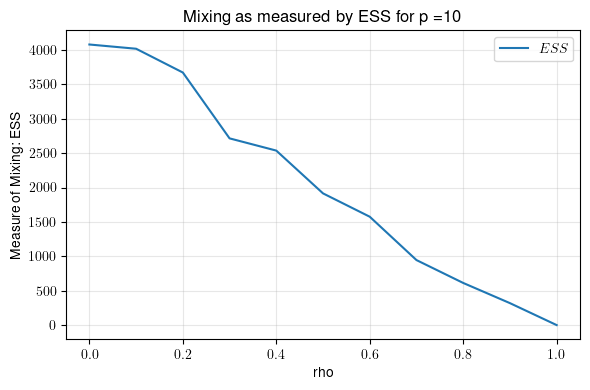

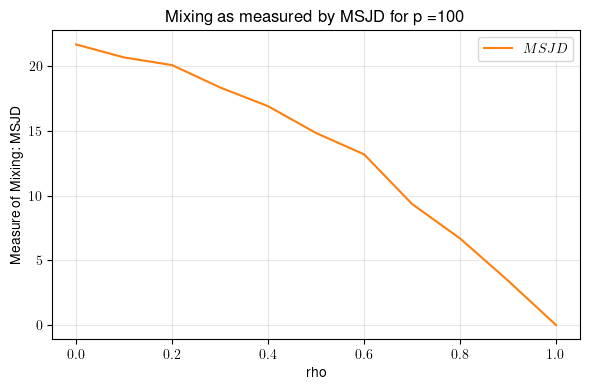

In [82]:
#Mixing as a function of rho
#Experiment 1

pmd = 100

delRho = .1
burnIn = 1000
NumSamps = 5000

ESSLstp100Ex1 = []
MSJDLstp100Ex1 = []
rhoLstp100Ex1 = []

rho = 0
while(rho < 1):
    rhoLstp100Ex1.append(rho)
    curSamp = MpCN(q0Ex1,NmParaEx1,CovEx1,rho,PotEx1,p,NumSamps)
    ESSLstp100Ex1.append(ess(curSamp[burnIn:,0]))
    MSJDLstp100Ex1.append(msjd(curSamp[burnIn:]))
    rho = rho + delRho

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp100Ex1, ESSLstp100Ex1, linestyle="-", label=r"$ESS$", color="tab:blue")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: ESS")
ax.set_title("Mixing as measured by ESS for p ="+str(pmd))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp100Ex1, MSJDLstp100Ex1, linestyle="-",label=r"$MSJD$", color="tab:orange")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: MSJD")
ax.set_title("Mixing as measured by MSJD for p ="+str(pmd))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

plt.show()

In [3]:
#Example 2: Statistical Inversion for the function f(x,y) = xy

#Specification of the forward problem (MM)
zdata = 6
sig = 1
fFn = lambda X : X[0]*X[1]
fFnStr = "xy"

NumParmsEx2 = 2

#LogLikihood function
PotEx2 = lambda X : (2* sig**2)**(-1) *(fFn(X) - zdata )**2

#Specifying the covariance
CovEVs = [3,2]
Tth = 2*np.pi/9

Rot = np.array([
        [np.cos(Tth), -np.sin(Tth)],
        [np.sin(Tth),  np.cos(Tth)]
    ])
Diag = np.diag(CovEVs)

#CovEx2 = Rot.T @ Diag @ Rot

CovEx2 = Diag


  
MpCN Run
Total samples generated: 10000
rho Value: 0.1
p Value: 100
  


  0%|          | 0/10 [00:00<?, ?it/s]

Number of failed runs: 0
Percentage of Failure: 0.0
Number of MpCN Samples Now Available: 10019


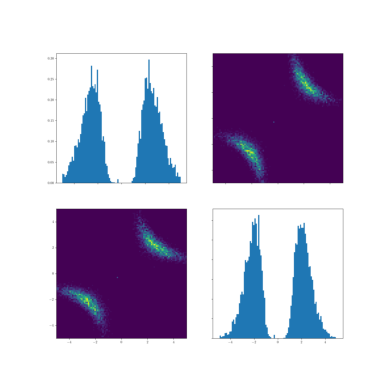

In [7]:
#Generate some test samples and visualization of Model Problem 2

#Specifying File Location to Save Data 

FileNmBase= "Data/Inversion_Toy/"

paraStr = "y_" + str(zdata)+ "_sig_" + str(sig) + "_fn_" + fFnStr+ "_Cov_" + str(CovEx2)
histFileNm = FileNmBase + "HIST" + paraStr + ".png"
csvFileNm = FileNmBase + "DATA" + paraStr + ".csv"

#Generate Data Using MpCN

#NumRuns =  5000 #of total runs
#NumSamps = 10000 #samples per run

NumRuns =  10 #of total runs
NumSamps = 1000 #samples per run



rho = .1
pSmp = 100

print("  ")
print("MpCN Run")
print("Total samples generated: " + str(NumRuns*NumSamps))

print("rho Value: " + str(rho))
print("p Value: " + str(pSmp))
print("  ")


badtryNm = 0




#Make mpCN Run Saving to .csv ensuring NAN errors do not stop the process

q0 = np.random.normal(0,1,NumParmsEx2)
for curRnInx in tqdm(range(0,NumRuns)):
    try:
        cursamps = MpCN(q0,NumParmsEx2,CovEx2,rho,PotEx2,pSmp,NumSamps +1)
        q0 = cursamps[0]
        writeCSV(csvFileNm,cursamps)
    except OverflowError:
        badtryNm = badtryNm +1

print("Number of failed runs: " + str(badtryNm))
print("Percentage of Failure: " + str(badtryNm/NumRuns))

#Make Histogram

mpCNsampTr = readCSV(csvFileNm)
samLenmpCN = len(mpCNsampTr)
print("Number of MpCN Samples Now Available: " + str(samLenmpCN))

#Dimensions For Histogram Plot
R = 5
dr = .1

makeHistGrid(R, dr, mpCNsampTr, NumParmsEx2,histFileNm, True)

img = mpimg.imread(histFileNm)
plt.imshow(img)
plt.axis('off')  # Turn off the axes
plt.show()

In [8]:
#Optimal tuning of rho for Example 2

pI = 1
pStep = 5
pF = 501


delRho = .01
burnIn = 1000
NumSamps = 5000

pLstEx2 = []
ESSrhoBestLstEx2 = []
ESSBestLstEx2 = []
MSJDrhoBestLstEx2 = []
MSJDBestLstEx2 = []

q0Ex2 = np.zeros(NumParmsEx2)
for p in tqdm(range(pI,pF,pStep)):
    rho = 0
    rhoBestESS = 0
    rhoBestMSJD = 0
    ESSBest = 0
    MSJDBest = 0
    while(rho < 1):
        curSamp = MpCN(q0Ex2,NumParmsEx2,CovEx2,rho,PotEx2,p,NumSamps)
        ESSCur = ess(curSamp[burnIn:,0])
        MSJDCur = msjd(curSamp[burnIn:])
        if ESSCur > ESSBest:
            ESSBest = ESSCur
            rhoBestESS = rho
        if MSJDCur > MSJDBest:
            MSJDBest = MSJDCur
            rhoBestMSJD = rho
        rho = rho + delRho
    pLstEx2.append(p)
    ESSBestLstEx2.append(ESSBest)
    ESSrhoBestLstEx2.append(rhoBestESS)
    MSJDBestLstEx2.append(MSJDBest)
    MSJDrhoBestLstEx2.append(rhoBestMSJD)

  0%|          | 0/10 [00:00<?, ?it/s]

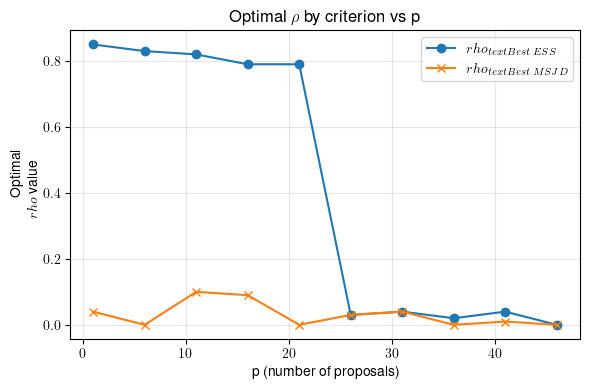

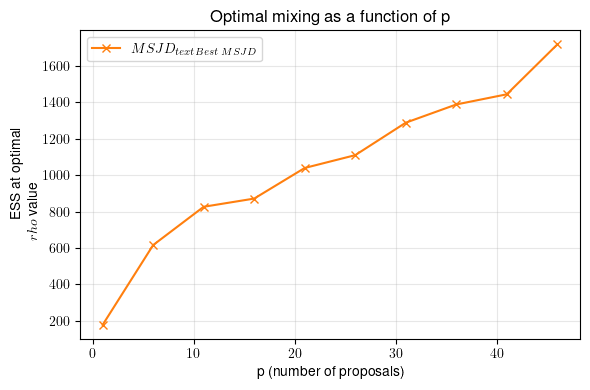

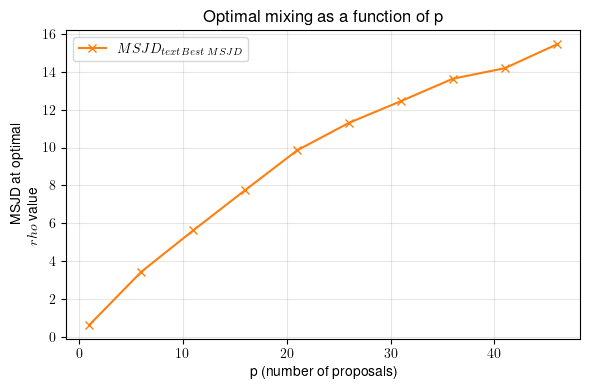

In [9]:
#Saving Experiment

FileNmBase= "Data/Inversion_Toy/"
ExpDes = "p_range_(" + str(pI) + "_"+ str(pF) +  "_"+ str(pStep) + ")rho_range_" + str(delRho)
csvFileNm = FileNmBase + ExpDes + ".csv"

writeCSV(csvFileNm,[pLstEx2,ESSBestLstEx2, ESSrhoBestLstEx2, MSJDBestLstEx2,MSJDrhoBestLstEx2])


#Some Plots

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(pLstEx2, ESSrhoBestLstEx2, marker="o", linestyle="-", label=r"$\\rho_{\\text{Best\,ESS}}$", color="tab:blue")
ax.plot(pLstEx2, MSJDrhoBestLstEx2, marker="x",linestyle="-",label=r"$\\rho_{\\text{Best\,MSJD}}$", color="tab:orange")

ax.set_xlabel("p (number of proposals)")
ax.set_ylabel(r"Optimal $\\rho$ value")
ax.set_title("Optimal $\\rho$ by criterion vs p")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(pLstEx2, ESSBestLstEx2, marker="x",linestyle="-",label=r"$\\MSJD_{\\text{Best\,MSJD}}$", color="tab:orange")

ax.set_xlabel("p (number of proposals)")
ax.set_ylabel(r"ESS at optimal $\\rho$ value")
ax.set_title("Optimal mixing as a function of p")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(pLstEx2, MSJDBestLstEx2, marker="x",linestyle="-",label=r"$\\MSJD_{\\text{Best\,MSJD}}$", color="tab:orange")

ax.set_xlabel("p (number of proposals)")
ax.set_ylabel(r"MSJD at optimal $\\rho$ value")
ax.set_title("Optimal mixing as a function of p")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

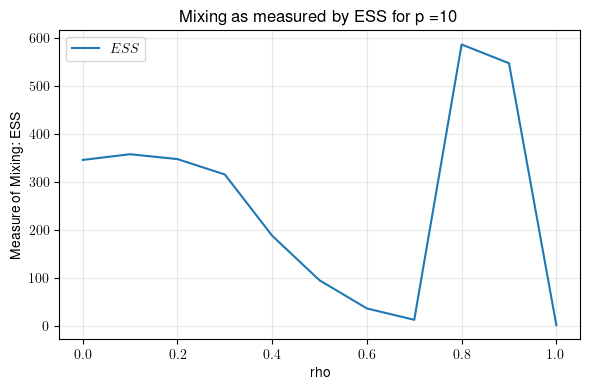

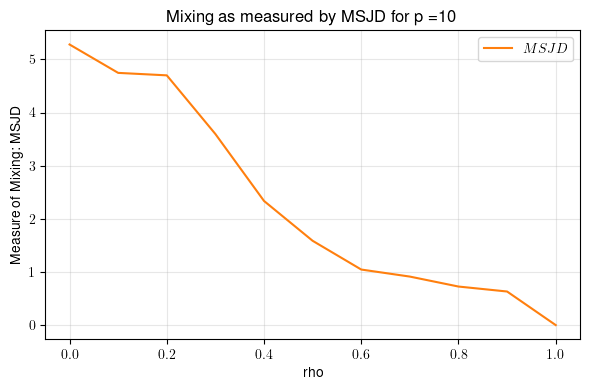

In [12]:
#Mixing as a function of rho
#Experiment 2

pmd = 10

delRho = .1
burnIn = 1000
NumSamps = 5000

ESSLstp100Ex2 = []
MSJDLstp100Ex2 = []
rhoLstp100Ex2 = []

rho = 0
while(rho < 1):
    rhoLstp100Ex2.append(rho)
    curSamp = MpCN(q0Ex2,NumParmsEx2,CovEx2,rho,PotEx2,pmd,NumSamps)
    ESSLstp100Ex2.append(ess(curSamp[burnIn:,0]))
    MSJDLstp100Ex2.append(msjd(curSamp[burnIn:]))
    rho = rho + delRho

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp100Ex2, ESSLstp100Ex2, linestyle="-", label=r"$ESS$", color="tab:blue")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: ESS")
ax.set_title("Mixing as measured by ESS for p ="+str(pmd))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp100Ex2, MSJDLstp100Ex2, linestyle="-",label=r"$MSJD$", color="tab:orange")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: MSJD")
ax.set_title("Mixing as measured by MSJD for p ="+str(pmd))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


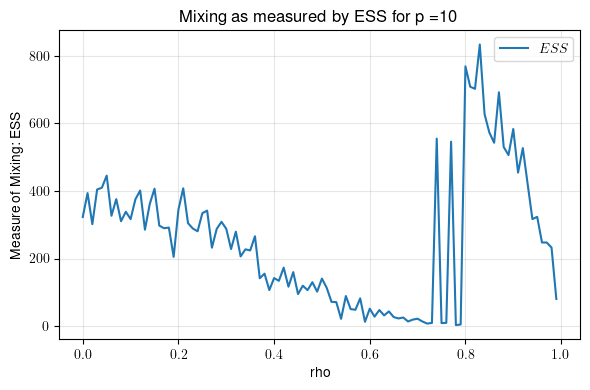

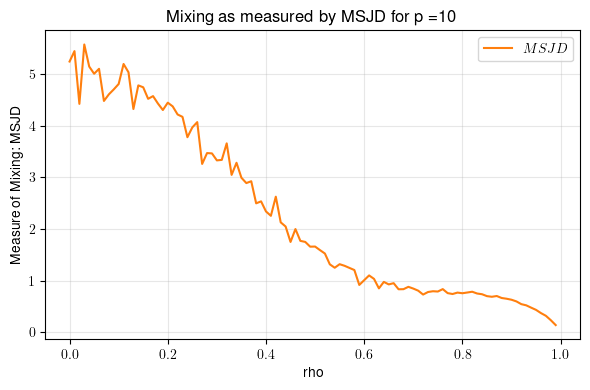

In [5]:
#Mixing as a function of rho
#Experiment 2
#Finner grid

pmd = 10

delRho = .01
burnIn = 1000
NumSamps = 5000

ESSLstp100Ex2 = []
MSJDLstp100Ex2 = []
rhoLstp100Ex2 = []

q0Ex2 = np.zeros(NumParmsEx2)
rho = 0
while(rho < 1):
    rhoLstp100Ex2.append(rho)
    curSamp = MpCN(q0Ex2,NumParmsEx2,CovEx2,rho,PotEx2,pmd,NumSamps)
    ESSLstp100Ex2.append(ess(curSamp[burnIn:,0]))
    MSJDLstp100Ex2.append(msjd(curSamp[burnIn:]))
    rho = rho + delRho

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp100Ex2, ESSLstp100Ex2, linestyle="-", label=r"$ESS$", color="tab:blue")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: ESS")
ax.set_title("Mixing as measured by ESS for p ="+str(pmd))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp100Ex2, MSJDLstp100Ex2, linestyle="-",label=r"$MSJD$", color="tab:orange")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: MSJD")
ax.set_title("Mixing as measured by MSJD for p ="+str(pmd))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

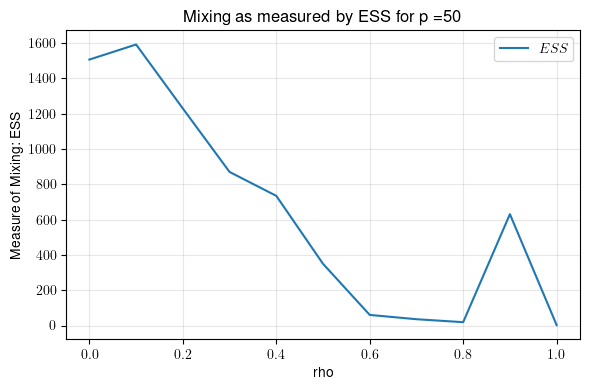

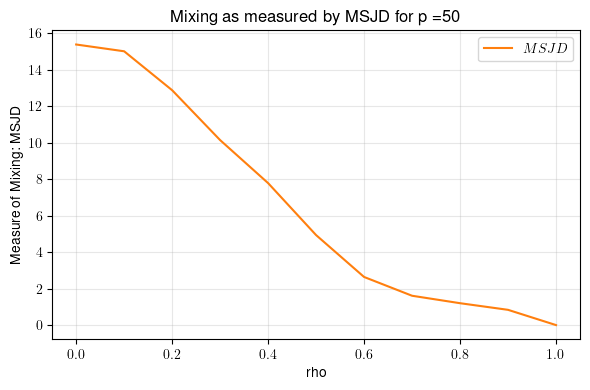

In [13]:
#Mixing as a function of rho
#Experiment 2

pmd = 50

delRho = .1
burnIn = 1000
NumSamps = 5000

ESSLstp100Ex2 = []
MSJDLstp100Ex2 = []
rhoLstp100Ex2 = []

rho = 0
while(rho < 1):
    rhoLstp100Ex2.append(rho)
    curSamp = MpCN(q0Ex2,NumParmsEx2,CovEx2,rho,PotEx2,pmd,NumSamps)
    ESSLstp100Ex2.append(ess(curSamp[burnIn:,0]))
    MSJDLstp100Ex2.append(msjd(curSamp[burnIn:]))
    rho = rho + delRho

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp100Ex2, ESSLstp100Ex2, linestyle="-", label=r"$ESS$", color="tab:blue")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: ESS")
ax.set_title("Mixing as measured by ESS for p ="+str(pmd))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp100Ex2, MSJDLstp100Ex2, linestyle="-",label=r"$MSJD$", color="tab:orange")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: MSJD")
ax.set_title("Mixing as measured by MSJD for p ="+str(pmd))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()


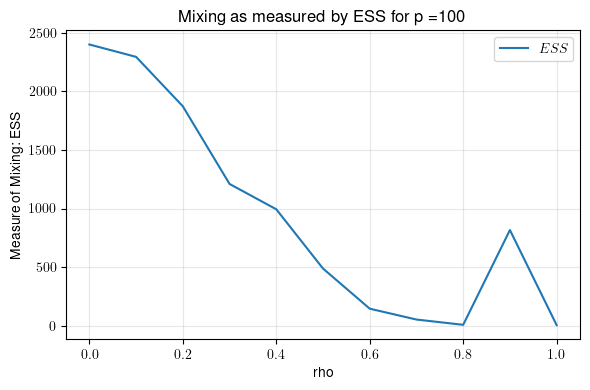

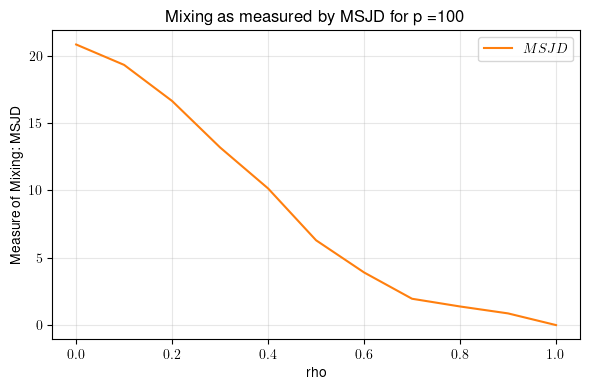

In [14]:
#Mixing as a function of rho
#Experiment 2

pmd = 100

delRho = .1
burnIn = 1000
NumSamps = 5000

ESSLstp100Ex2 = []
MSJDLstp100Ex2 = []
rhoLstp100Ex2 = []

rho = 0
while(rho < 1):
    rhoLstp100Ex2.append(rho)
    curSamp = MpCN(q0Ex2,NumParmsEx2,CovEx2,rho,PotEx2,pmd,NumSamps)
    ESSLstp100Ex2.append(ess(curSamp[burnIn:,0]))
    MSJDLstp100Ex2.append(msjd(curSamp[burnIn:]))
    rho = rho + delRho

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp100Ex2, ESSLstp100Ex2, linestyle="-", label=r"$ESS$", color="tab:blue")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: ESS")
ax.set_title("Mixing as measured by ESS for p ="+str(pmd))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp100Ex2, MSJDLstp100Ex2, linestyle="-",label=r"$MSJD$", color="tab:orange")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: MSJD")
ax.set_title("Mixing as measured by MSJD for p ="+str(pmd))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

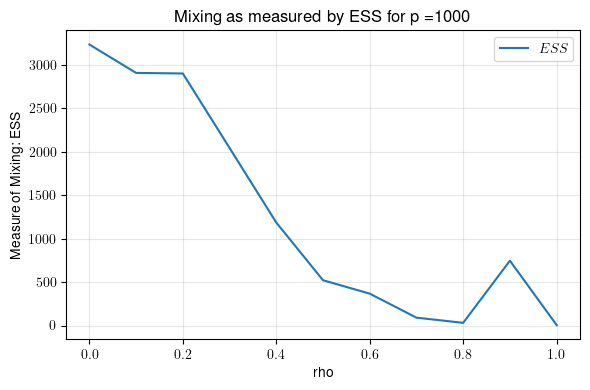

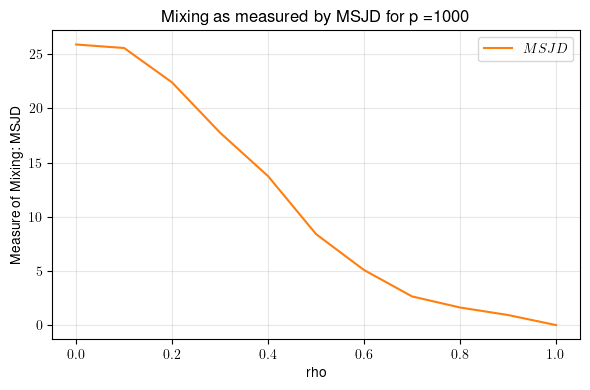

In [15]:
#Mixing as a function of rho
#Experiment 2

pmd = 1000

delRho = .1
burnIn = 1000
NumSamps = 5000

ESSLstp100Ex2 = []
MSJDLstp100Ex2 = []
rhoLstp100Ex2 = []

rho = 0
while(rho < 1):
    rhoLstp100Ex2.append(rho)
    curSamp = MpCN(q0Ex2,NumParmsEx2,CovEx2,rho,PotEx2,pmd,NumSamps)
    ESSLstp100Ex2.append(ess(curSamp[burnIn:,0]))
    MSJDLstp100Ex2.append(msjd(curSamp[burnIn:]))
    rho = rho + delRho

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp100Ex2, ESSLstp100Ex2, linestyle="-", label=r"$ESS$", color="tab:blue")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: ESS")
ax.set_title("Mixing as measured by ESS for p ="+str(pmd))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp100Ex2, MSJDLstp100Ex2, linestyle="-",label=r"$MSJD$", color="tab:orange")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: MSJD")
ax.set_title("Mixing as measured by MSJD for p ="+str(pmd))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [3]:
#Example 3:  Reduced Dimensional Advection-Diffusion Toy Model for larger scale studies

#Specifying Problem Parameters

#Model Dimension and Parameter Size

ModDm = 3 #Size of the matrix
NumParms = int(ModDm*(ModDm -1)/2)


#The Forward Model entails solving for th(A) for any antisymmetric A where
# (A + kap I) th = g 
# so that th(A) = th_{k,g}

# g = (g0, g1, g2)^T

g0 = 1
g1 = 1
g2 = -1

g = np.transpose(np.array([g0,g1,g2]))

# Coefficent of the `regularization/diffusion term'
kap = .1

#Specification `observed data' y0, y1
#Note, when A = 0, \th(A) =  kap^{-1} g.  So we specify y as y = \th(A) + \epsilon
eps0 = .3
eps1 = .1
y0 = kap**(-1)*g0 + eps0
y1 = kap**(-1)*g1 + eps1

y = [y0,y1]

yData = np.array([y0,y1,0])

# `observation noise coefficent'

sig = 2

# Covariance of the 'prior' C = cov0[1^{-gam}, 2^[-gam],..., N^{-gam}]
# where N is the number of parameters in the model NumParms = 6 
#for number of enetries that need to be specified in A

cov0 = 5
gam = 1.5

# Specify Potential and Prior Covariance
# The Posterior is of the form
# mu(dA) = Z^{-1} \exp( -1/(2 sig^2) ( (y0 - th(A)(0))^2 +(y1 - th(A)(1))^2 ) mu_0(dA)
# where
# mu_0(dA) = Z^{-1}_0 \exp( - 1/2<C^{-1}A, A>)

idx = np.triu_indices(ModDm, 1)

def getThAN(aPar,b,kappa):
    A_pkI = np.zeros((ModDm, ModDm))
    i, j = idx
    A_pkI[i, j] = aPar
    A_pkI[j, i] = -aPar
    A_pkI[np.diag_indices(ModDm)] += kappa
    return np.linalg.solve(A_pkI, b)

Poty = lambda a : (2*sig**2)**(-1)*(norm(y - getThAN(a, g, kap)[0:2]))**2
CovDiag = [cov0* (j**(-gam)) for j in list(range(1,NumParms+1))]

#Code to generate a random orthogonal matrix (uniform from O(n)) using the QR factorization of a Guassian matrix.
def rndm_orth_matrix(n):

    #Generate a random n x n matrix with i.i.d. normal entries
    A = np.random.randn(n, n)
    
    #Perform the QR factorization
    Q, R = np.linalg.qr(A)    
    
    return Q

#Code to 'rotate' baseline covariance
#Q = rndm_orth_matrix(NumParms)  
#Cov = Q.T@ mkDiagCov(CovDiag)@ Q
#print(Cov)

Cov = np.array([[3.65372175, -1.55416548, 0.86796861],[-1.55416548, 1.90906562, -0.7149217 ],[ 0.86796861, -0.7149217, 2.16723004]])

  
MpCN Run
Total samples generated: 10000
rho Value: 0.1
p Value: 100
  


  0%|          | 0/10 [00:00<?, ?it/s]

Number of failed runs: 0
Percentage of Failure: 0.0
Number of MpCN Samples Now Available: 10019


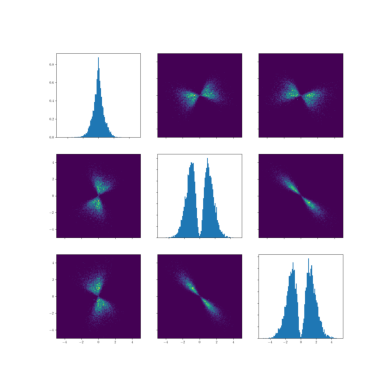

In [3]:
#Generate some test samples and visualization of Model Problem 3

#Specifying File Location to Save Data 

FileNmBase= "Data/Advection_Diffusion_Toy/"

paraStr = "gvec_" + str(g) + "_kap_" + str(kap) + "_y_" + str(y)+ "_sig_" + str(sig) + "_Cov_" + str(Cov)
histFileNm = FileNmBase + "HIST" + paraStr + ".png"
csvFileNm = FileNmBase + "DATA" + paraStr + ".csv"

#Generate Data Using MpCN

#NumRuns =  5000 #of total runs
#NumSamps = 10000 #samples per run

NumRuns =  10 #of total runs
NumSamps = 1000 #samples per run



rho = .1
pSmp = 100

print("  ")
print("MpCN Run")
print("Total samples generated: " + str(NumRuns*NumSamps))

print("rho Value: " + str(rho))
print("p Value: " + str(pSmp))
print("  ")


badtryNm = 0




#Make mpCN Run Saving to .csv ensuring NAN errors do not stop the process

q0 = np.random.normal(0,1,NumParms)
for curRnInx in tqdm(range(0,NumRuns)):
    try:
        cursamps = MpCN(q0,NumParms,Cov,rho,Poty,pSmp,NumSamps +1)
        q0 = cursamps[0]
        writeCSV(csvFileNm,cursamps)
    except OverflowError:
        badtryNm = badtryNm +1

print("Number of failed runs: " + str(badtryNm))
print("Percentage of Failure: " + str(badtryNm/NumRuns))

#Make Histogram

mpCNsampTr = readCSV(csvFileNm)
samLenmpCN = len(mpCNsampTr)
print("Number of MpCN Samples Now Available: " + str(samLenmpCN))

#Dimensions For Histogram Plot
R = 5
dr = .1

makeHistGrid(R, dr, mpCNsampTr, NumParms,histFileNm, True)

img = mpimg.imread(histFileNm)
plt.imshow(img)
plt.axis('off')  # Turn off the axes
plt.show()


In [4]:
#Optimal tuning of rho for Example 3

pI = 1
pStep = 5
pF = 101


delRho = .01
burnIn = 1000
NumSamps = 5000

pLstEx3 = []
ESSrhoBestLstEx3 = []
ESSBestLstEx3 = []
MSJDrhoBestLstEx3 = []
MSJDBestLstEx3 = []

q0Ex3 = np.zeros(NumParms)
for p in tqdm(range(pI,pF,pStep)):
    rho = 0
    rhoBestESS = 0
    rhoBestMSJD = 0
    ESSBest = 0
    MSJDBest = 0
    while(rho < 1):
        curSamp = MpCN(q0Ex3,NumParms,Cov,rho,Poty,p,NumSamps)
        ESSCur = ess(curSamp[burnIn:,0])
        MSJDCur = msjd(curSamp[burnIn:])
        if ESSCur > ESSBest:
            ESSBest = ESSCur
            rhoBestESS = rho
        if MSJDCur > MSJDBest:
            MSJDBest = MSJDCur
            rhoBestMSJD = rho
        rho = rho + delRho
    pLstEx3.append(p)
    ESSBestLstEx3.append(ESSBest)
    ESSrhoBestLstEx3.append(rhoBestESS)
    MSJDBestLstEx3.append(MSJDBest)
    MSJDrhoBestLstEx3.append(rhoBestMSJD)

  0%|          | 0/20 [00:00<?, ?it/s]

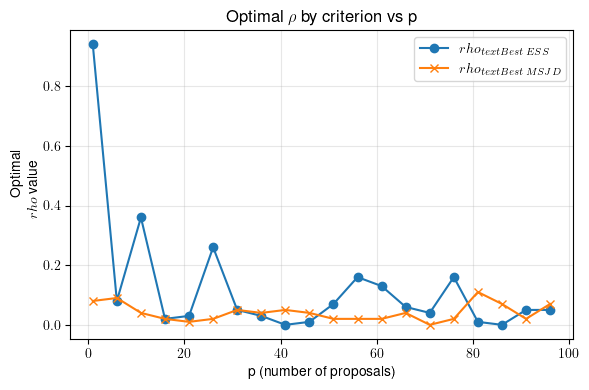

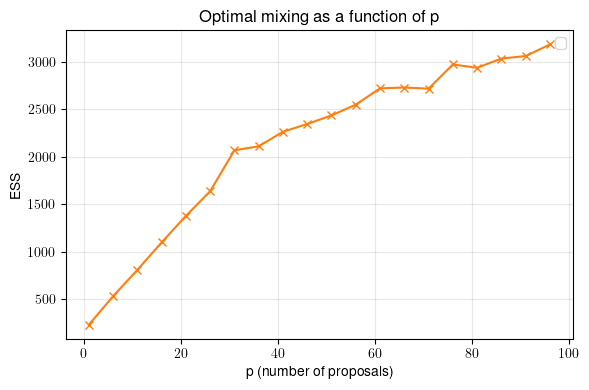

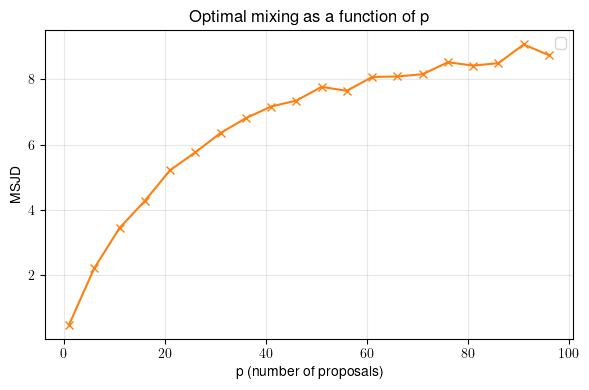

In [9]:
#Saving Experiment

FileNmBase= "Data/Advection_Diffusion_Toy/"
ExpDes = "p_range_(" + str(pI) + "_"+ str(pF) +  "_"+ str(pStep) + ")rho_range_" + str(delRho)
csvFileNm = FileNmBase + ExpDes + ".csv"

writeCSV(csvFileNm,[pLstEx3,ESSBestLstEx3, ESSrhoBestLstEx3, MSJDBestLstEx3,MSJDrhoBestLstEx3])


#Some Plots

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(pLstEx3, ESSrhoBestLstEx3, marker="o", linestyle="-", label=r"$\\rho_{\\text{Best\,ESS}}$", color="tab:blue")
ax.plot(pLstEx3, MSJDrhoBestLstEx3, marker="x",linestyle="-",label=r"$\\rho_{\\text{Best\,MSJD}}$", color="tab:orange")

ax.set_xlabel("p (number of proposals)")
ax.set_ylabel(r"Optimal $\\rho$ value")
ax.set_title("Optimal $\\rho$ by criterion vs p")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(pLstEx3, ESSBestLstEx3, marker="x",linestyle="-", color="tab:orange")

ax.set_xlabel("p (number of proposals)")
ax.set_ylabel(r"ESS")
ax.set_title("Optimal mixing as a function of p")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(pLstEx3, MSJDBestLstEx3, marker="x",linestyle="-", color="tab:orange")

ax.set_xlabel("p (number of proposals)")
ax.set_ylabel(r"MSJD")
ax.set_title("Optimal mixing as a function of p")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [16]:
#First experiment in optimal tuning of rho for Experiment 3

pI = 1
pStep = 1
pF = 100


delRho = .01
burnIn = 1000
NumSamps = 5000

pLst = []
ESSrhoBestLst = []
ESSBestLst = []
MSJDrhoBestLst = []
MSJDBestLst = []

for p in tqdm(range(pI,pF,pStep)):
    rho = 0
    rhoBestESS = 0
    rhoBestMSJD = 0
    ESSBest = 0
    MSJDBest = 0
    while(rho < 1):
        curSamp = MpCN(q0,NumParms,Cov,rho,Poty,p,NumSamps)
        ESSCur = ess(curSamp[burnIn:,0])
        MSJDCur = msjd(curSamp[burnIn:])
        if ESSCur > ESSBest:
            ESSBest = ESSCur
            rhoBestESS = rho
        if MSJDCur > MSJDBest:
            MSJDBest = MSJDCur
            rhoBestMSJD = rho
        rho = rho + delRho
    pLst.append(p)
    ESSBestLst.append(ESSBest)
    ESSrhoBestLst.append(rhoBestESS)
    MSJDBestLst.append(MSJDBest)
    MSJDrhoBestLst.append(rhoBestMSJD)

  
    
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(pLst, ESSrhoBestLst, marker="o", linestyle="-", label=r"$\\rho_{\\text{Best\,ESS}}$", color="tab:blue")
ax.plot(pLst, MSJDrhoBestLst, marker="x",linestyle="-",label=r"$\\rho_{\\text{Best\,MSJD}}$", color="tab:orange")

ax.set_xlabel("p (number of proposals)")
ax.set_ylabel(r"Optimal $\\rho$ value")
ax.set_title("Optimal $\\rho$ by criterion vs p")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

        


  0%|          | 0/99 [00:00<?, ?it/s]

NameError: name 'NumParms' is not defined

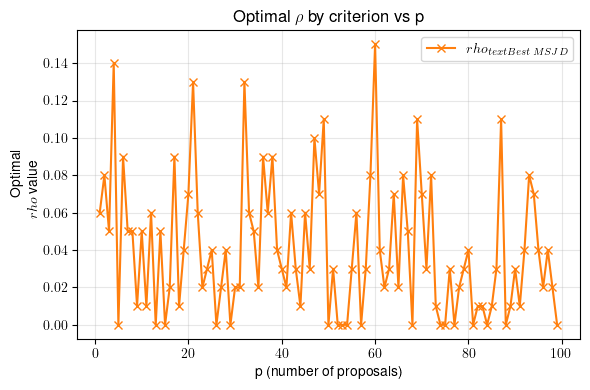

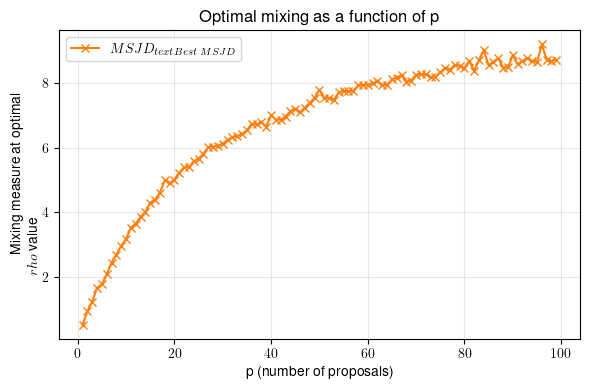

In [44]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(pLst, MSJDrhoBestLst, marker="x",linestyle="-",label=r"$\\rho_{\\text{Best\,MSJD}}$", color="tab:orange")

ax.set_xlabel("p (number of proposals)")
ax.set_ylabel(r"Optimal $\\rho$ value")
ax.set_title("Optimal $\\rho$ by criterion vs p")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()



fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(pLst, MSJDBestLst, marker="x",linestyle="-",label=r"$\\MSJD_{\\text{Best\,MSJD}}$", color="tab:orange")

ax.set_xlabel("p (number of proposals)")
ax.set_ylabel(r"Mixing measure at optimal $\\rho$ value")
ax.set_title("Optimal mixing as a function of p")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()



In [36]:
#Studies of mixing as function of rho for different numbers of proposals p

#small
psm = 10

delRho = .01
burnIn = 1000
NumSamps = 10000

ESSLstp10 = []
MSJDLstp10 = []
rhoLstp10 = []

rho=0
while(rho < 1):
    rhoLstp10.append(rho)
    curSamp = MpCN(q0,NumParms,Cov,rho,Poty,psm,NumSamps)
    ESSLstp10.append(ess(curSamp[burnIn:,0]))
    MSJDLstp10.append(msjd(curSamp[burnIn:]))
    rho = rho + delRho






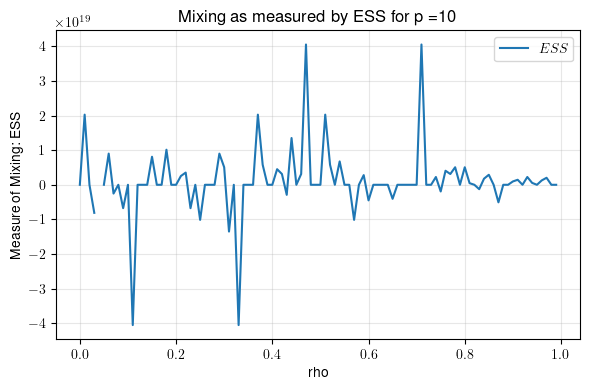

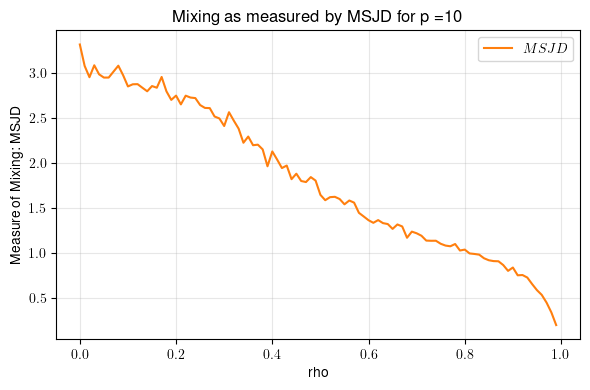

In [37]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp10, ESSLstp10, linestyle="-", label=r"$ESS$", color="tab:blue")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: ESS")
ax.set_title("Mixing as measured by ESS for p ="+str(psm))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp10, MSJDLstp10, linestyle="-",label=r"$MSJD$", color="tab:orange")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: MSJD")
ax.set_title("Mixing as measured by MSJD for p ="+str(psm))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

plt.show()


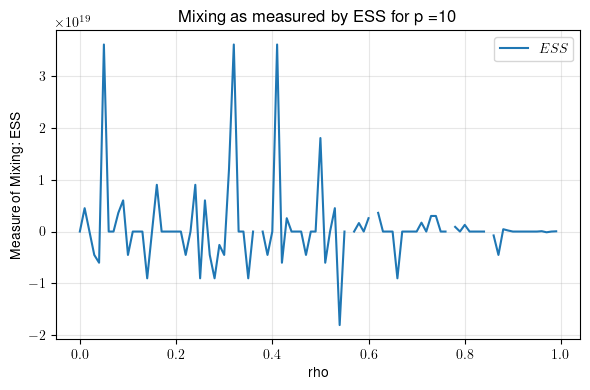

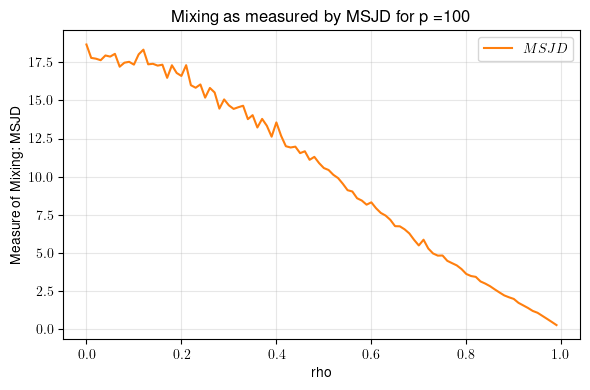

In [39]:
#Medium
pmd = 100

delRho = .01
burnIn = 1000
NumSamps = 5000

ESSLstp100 = []
MSJDLstp100 = []
rhoLstp100 = []

rho = 0
while(rho < 1):
    rhoLstp100.append(rho)
    curSamp = MpCN(q0,NumParms,Cov,rho,Poty,pmd,NumSamps)
    ESSLstp100.append(ess(curSamp[burnIn:,0]))
    MSJDLstp100.append(msjd(curSamp[burnIn:]))
    rho = rho + delRho

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp100, ESSLstp100, linestyle="-", label=r"$ESS$", color="tab:blue")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: ESS")
ax.set_title("Mixing as measured by ESS for p ="+str(psm))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

plt.show()

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(rhoLstp100, MSJDLstp100, linestyle="-",label=r"$MSJD$", color="tab:orange")

ax.set_xlabel("rho")
ax.set_ylabel(r"Measure of Mixing: MSJD")
ax.set_title("Mixing as measured by MSJD for p ="+str(pmd))
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

plt.show()

